# Inicio da analise
Com o dataframe analitico gerado vamos começar a analise exploratoria para responder a seguinte pergunta:
__É possível identificar associação estatística entre o modelo de urna eletrônica utilizado em uma seção e a distribuição agregada dos votos para presidente no segundo turno de 2022, depois de considerar diferenças geográficas e de composição eleitoral?__



# Estratégia de análise adotada: Investigação do Efeito do Modelo da Urna nas Eleições Presidenciais de 2022

O Desafio Econométrico: Viés de Seleção GeográficaA distribuição das urnas UE2020 em 2022 não foi um experimento puramente aleatório em nível nacional. Capitais, regiões metropolitanas e certos estados receberam fatias maiores do novo lote industrial, enquanto cidades menores e zonas rurais mantiveram proporções distintas de máquinas legadas.Se fizéssemos uma comparação ingênua de médias nacionais (ex.: teste $t$ simples entre o total de votos em UE2020 vs. legadas), o resultado capturaria apenas o alinhamento político regional (voto urbano vs. voto rural, diferenças regionais de renda e escolaridade), gerando uma correlação espúria.Para isolar o efeito real, adotamos uma estratégia em duas camadas:Camada Paramétrica Global: Regressão com Efeitos Fixos e Controles Sociodemográficos (cobertura nacional total).Camada Quase-Experimental Local: Pareamento Quase-Perfeito dentro de Locais de Votação Mistos (mesma escola).2. Camada 1 (Análise Principal): Regressão Linear com Efeitos Fixos de Município/ZonaPor que escolhemos utilizar (Vantagens):Eliminação de Variação Inobservada Entre Cidades: Ao introduzir efeitos fixos em nível de município ($\mu_m$), a regressão descarta todas as diferenças geográficas, culturais, orçamentárias e regionais que existem entre cidades. A comparação dos votos passa a ser feita estritamente entre urnas alocadas dentro do mesmo município.Controle Multivariado Simultâneo: Permite descontar diferenças contínuas de escolaridade, faixa etária e abstenção que existam mesmo dentro de um mesmo município.Validade Estatística em Larga Escala: Utiliza todas as ~471 mil seções integradas do país com erros-padrão clusterizados por município, prevenindo falsos positivos decorrentes de correlação espacial entre seções vizinhas.Especificação do Modelo:$$Y_{is} = \alpha + \beta_1 \cdot \text{IS\_UE2020}_{is} + \mathbf{X}_{is}'\boldsymbol{\gamma} + \mu_{m} + \varepsilon_{is}$$$Y_{is}$ (Variável Dependente): Proporção de votos válidos de um dos candidatos (ex.: $\text{PROP\_LULA} = \frac{\text{Votos Lula}}{\text{Votos Lula} + \text{Votos Bolsonaro}}$).$\text{IS\_UE2020}_{is}$ (Variável de Tratamento): $1$ se a seção utilizou urna modelo 2020; $0$ se utilizou urna legada.$\mathbf{X}_{is}$ (Vetor de Controles Demográficos por Seção):Proporção com ensino superior (PROP_SUPERIOR)Proporção de baixa escolaridade / analfabetos (PROP_BAIXA_ESC)Proporção de eleitores idosos $\ge 60$ anos (PROP_IDOSOS)Proporção de eleitores jovens $\le 24$ anos (PROP_JOVENS)Proporção de mulheres (PROP_FEMININO)Taxa de abstenção da seção (PROP_ABSTENCAO)$\mu_m$: Efeito fixo por código de município (CD_MUNICIPIO) ou zona eleitoral (NR_ZONA).Erros-padrão: Clusterizados no nível municipal.Critério de Decisão:Hipótese Nula ($H_0: \beta_1 = 0$): O hardware da urna não possui impacto sistemático no percentual de votos recebidos.Se o intervalo de confiança de $\beta_1$ contiver o zero ($p > 0.05$) ou apresentar magnitude economicamente desprezível ($\beta_1 \approx 0{,}000$), a hipótese de impacto do equipamento é refutada.3. Camada 2 (Teste de Robustez): Dispersão em Locais de Votação MistosPor que escolhemos utilizar (Vantagens):Independência de Forma Funcional: Não depende de premissas de linearidade da regressão.Controle Quase-Experimental Perfeito: Dentro da mesma escola ou colégio eleitoral (NR_LOCAL_VOTACAO), os eleitores pertencem ao mesmo bairro, mesma classe socioeconômica e votaram sob as mesmas condições climáticas e operacionais.Intuitividade e Auditabilidade: Se houver um local com 6 salas onde 3 usaram modelo 2020 e 3 usaram modelos antigos, qualquer desvio sistemático entre essas salas não pode ser atribuído a fatores macroeconômicos ou regionais.Metodologia da Camada 2:Identificação dos Locais Mistos: Filtrar apenas os locais de votação que tiveram simultaneamente pelo menos uma urna UE2020 e pelo menos uma urna legada.Cálculo do Diferencial Intra-Local: Para cada local de votação misto $k$:$$\Delta_k = \bar{Y}_{k, \text{UE2020}} - \bar{Y}_{k, \text{Legadas}}$$Distribuição Empírica de $\Delta$:Avaliar a média ponderada de $\Delta_k$ no Brasil e por região.Realizar teste $t$ pareado / teste de postos sinalizados de Wilcoxon.Plotar o histograma de diferenças dentro do local (espera-se uma curva normal simétrica centrada estritamente em zero).


# Carregamento e preparação das variaveis
Neste primeiro bloco, lemos o arquivo persistido e geramos:VOTOS_VALIDOS: Soma de Lula e Bolsonaro na seção.PROP_LULA: Percentual de votos válidos recebidos por Lula na seção ($Y_{is}$).PROP_BOLSONARO: Percentual de votos válidos de Bolsonaro.PROP_ABSTENCAO: Taxa de abstenção em relação aos eleitores aptos da seção.

In [1]:
import pandas as pd
import numpy as np

# 1. Leitura do Parquet consolidado
caminho_parquet = "df_analitico/df_analise_eleicoes_2022.parquet"
df = pd.read_parquet(caminho_parquet)
print(f"Dataset carregado com sucesso: {len(df):,} seções eleitorais.")

# 2. Construção das variáveis dependentes e de controle adicionais
df['VOTOS_VALIDOS'] = df['LULA'] + df['JAIR BOLSONARO']

# Filtra seções que tiveram pelo menos 1 voto válido
df = df[df['VOTOS_VALIDOS'] > 0].copy()

df['PROP_LULA'] = df['LULA'] / df['VOTOS_VALIDOS']
df['PROP_BOLSONARO'] = df['JAIR BOLSONARO'] / df['VOTOS_VALIDOS']

# Taxa de abstenção
df['PROP_ABSTENCAO'] = np.where(
    df['QT_APTOS'] > 0,
    df['QT_ABSTENCOES'] / df['QT_APTOS'],
    0
)

# 3. Tratamento de nulos nas variáveis sociodemográficas (se houver)
colunas_controles = [
    'PROP_SUPERIOR', 'PROP_BAIXA_ESC', 
    'PROP_FEMININO', 'PROP_JOVENS', 'PROP_IDOSOS', 'PROP_ABSTENCAO'
]
df[colunas_controles] = df[colunas_controles].fillna(0)

print(f"Seções válidas para modelagem: {len(df):,}")

Dataset carregado com sucesso: 471,691 seções eleitorais.
Seções válidas para modelagem: 471,691


## Passo 2: Diagnóstico Exploratório Ingênuo (Baseline)

Antes de aplicar os efeitos fixos, é comum rodar uma comparação simples para evidenciar o viés inicial decorrente da distribuição geográfica das urnas:

In [2]:
# Média ingênua de votação por tipo de urna (sem nenhum controle geográfico)
resumo_ingenuo = df.groupby('IS_UE2020').agg(
    total_secoes=('NR_SECAO', 'count'),
    media_lula=('PROP_LULA', 'mean'),
    media_bolsonaro=('PROP_BOLSONARO', 'mean')
).rename(index={0: 'Legadas (2009-2015)', 1: 'UE2020'})

print("--- Comparação Simples (Ingênua / Sem Controles) ---")
print((resumo_ingenuo * [1, 100, 100]).round(2))

--- Comparação Simples (Ingênua / Sem Controles) ---
                     total_secoes  media_lula  media_bolsonaro
IS_UE2020                                                     
Legadas (2009-2015)        279184       53.37            46.63
UE2020                     192507       49.18            50.82


## Passo 3: Modelagem Econométrica com Efeitos Fixos (Camada 1)

Vamos agora rodar a regressão sequencial para verificar se esses 4,19 p.p. resistem quando controlamos:

As características sociodemográficas dos eleitores (PROP_SUPERIOR, PROP_BAIXA_ESC, etc.).

O município de votação (efeitos fixos de CD_MUNICIPIO).

Para estimar efeitos fixos com mais de 5.500 municípios de forma rápida e eficiente sem estourar a memória (usando projeção dentro do grupo), a biblioteca pyfixest ou linearmodels é ideal. Alternativamente, podemos absorver o efeito fixo via desvio da média (within transformation) nativamente no Pandas/Statsmodels:

In [ ]:
pip install statsmodels

In [6]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# -------------------------------------------------------------
# Modelo 1: Bivariado Ingênuo (Regressão OLS Simples)
# -------------------------------------------------------------
mod_1 = smf.ols('PROP_LULA ~ IS_UE2020', data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['CD_MUNICIPIO']}
)
print("=== MODELO 1: Ingênuo (Bivariado) ===")
print(mod_1.summary().tables[1])

# -------------------------------------------------------------
# Modelo 2: OLS com Controles Sociodemográficos (Sem Efeito Fixo)
# -------------------------------------------------------------
formula_mod2 = (
    'PROP_LULA ~ IS_UE2020 + PROP_SUPERIOR + PROP_BAIXA_ESC + '
    'PROP_FEMININO + PROP_JOVENS + PROP_IDOSOS + PROP_ABSTENCAO'
)
mod_2 = smf.ols(formula_mod2, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['CD_MUNICIPIO']}
)
print("\n=== MODELO 2: Controles Sociodemográficos ===")
print(mod_2.summary().tables[1])

=== MODELO 1: Ingênuo (Bivariado) ===
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5337      0.004    121.843      0.000       0.525       0.542
IS_UE2020     -0.0419      0.010     -4.214      0.000      -0.061      -0.022

=== MODELO 2: Controles Sociodemográficos ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.2417      0.015     16.116      0.000       0.212       0.271
IS_UE2020          0.0227      0.009      2.476      0.013       0.005       0.041
PROP_SUPERIOR     -0.0524      0.025     -2.119      0.034      -0.101      -0.004
PROP_BAIXA_ESC     1.0362      0.028     36.567      0.000       0.981       1.092
PROP_FEMININO      0.3947      0.029     13.448      0.000       0.337       0.452
PROP_JOVENS       

In [7]:
# -------------------------------------------------------------
# Modelo 3: Efeitos Fixos de Município (Within-Transformation)
# Compara urnas UE2020 vs Legadas estritamente DENTRO do mesmo município
# -------------------------------------------------------------
vars_modelo = [
    'PROP_LULA', 'IS_UE2020', 'PROP_SUPERIOR', 'PROP_BAIXA_ESC',
    'PROP_FEMININO', 'PROP_JOVENS', 'PROP_IDOSOS', 'PROP_ABSTENCAO'
]

# Subtrai a média municipal de cada variável
df_dm = df[vars_modelo].copy()
for col in vars_modelo:
    df_dm[col] = df_dm[col] - df.groupby('CD_MUNICIPIO')[col].transform('mean')

formula_fe = (
    'PROP_LULA ~ IS_UE2020 + PROP_SUPERIOR + PROP_BAIXA_ESC + '
    'PROP_FEMININO + PROP_JOVENS + PROP_IDOSOS + PROP_ABSTENCAO - 1'
)

mod_fe = smf.ols(formula_fe, data=df_dm).fit(
    cov_type='cluster', cov_kwds={'groups': df['CD_MUNICIPIO']}
)

print("\n=== MODELO 3: EFEITOS FIXOS DE MUNICÍPIO + CONTROLES ===")
print(mod_fe.summary().tables[1])


=== MODELO 3: EFEITOS FIXOS DE MUNICÍPIO + CONTROLES ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
IS_UE2020          0.0006      0.003      0.194      0.846      -0.005       0.006
PROP_SUPERIOR     -0.1159      0.029     -3.981      0.000      -0.173      -0.059
PROP_BAIXA_ESC     0.5001      0.021     23.665      0.000       0.459       0.542
PROP_FEMININO      0.0973      0.011      8.890      0.000       0.076       0.119
PROP_JOVENS        0.1236      0.006     19.300      0.000       0.111       0.136
PROP_IDOSOS       -0.1359      0.015     -9.131      0.000      -0.165      -0.107
PROP_ABSTENCAO     0.0184      0.032      0.577      0.564      -0.044       0.081


In [9]:
chave_cluster = ['CD_MUNICIPIO', 'NR_ZONA']
nome_unidade = "Zonas Eleitorais"

In [ ]:
pip install scipy matplotlib seaborn

In [12]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 2. Filtrar apenas clusters MISTOS (que possuem pelo menos uma UE2020 e uma Legada)
contagem_modelos = df.groupby(chave_cluster)['IS_UE2020'].nunique()
clusters_mistos = contagem_modelos[contagem_modelos > 1].index

df_mistos = df.set_index(chave_cluster).loc[clusters_mistos].reset_index()

print(f"Total de {nome_unidade.lower()} mistos: {len(clusters_mistos):,}")
print(f"Total de seções analisadas nesse recorte: {len(df_mistos):,}")

# 3. Calcular a média de votos de cada modelo dentro de cada cluster
medias_cluster = df_mistos.groupby(chave_cluster + ['IS_UE2020'])['PROP_LULA'].mean().unstack()
medias_cluster.columns = ['MEDIA_LEGADAS', 'MEDIA_UE2020']

# 4. Calcular o diferencial (Delta = UE2020 - Legadas)
medias_cluster['DELTA'] = medias_cluster['MEDIA_UE2020'] - medias_cluster['MEDIA_LEGADAS']
medias_cluster = medias_cluster.dropna()

delta_medio = medias_cluster['DELTA'].mean()
delta_mediano = medias_cluster['DELTA'].median()
std_delta = medias_cluster['DELTA'].std()

# Teste t pareado
t_stat, p_val = stats.ttest_1samp(medias_cluster['DELTA'], 0.0)

print("\n--- Resultados da Análise de Unidades Mistas ---")
print(f"Diferença Média (UE2020 - Legadas): {delta_medio * 100:+.3f} p.p.")
print(f"Diferença Mediana: {delta_mediano * 100:+.3f} p.p.")
print(f"Desvio-Padrão da Diferença: {std_delta * 100:.3f} p.p.")
print(f"Estatística t: {t_stat:.4f} | Valor-p: {p_val:.4f}")

Total de zonas eleitorais mistos: 460
Total de seções analisadas nesse recorte: 102,700

--- Resultados da Análise de Unidades Mistas ---
Diferença Média (UE2020 - Legadas): -1.750 p.p.
Diferença Mediana: -1.472 p.p.
Desvio-Padrão da Diferença: 5.313 p.p.
Estatística t: -7.0625 | Valor-p: 0.0000


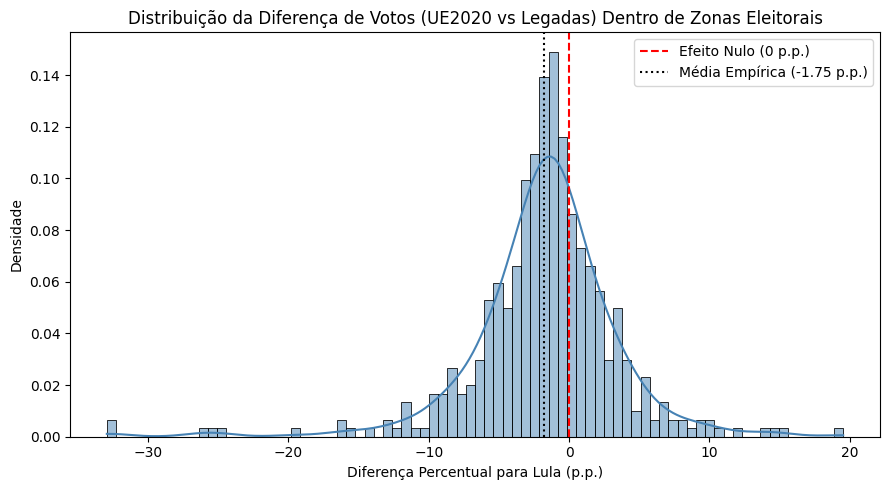

In [14]:
# Gráfico da distribuição empírica das diferenças intra-unidade
plt.figure(figsize=(9, 5))
sns.histplot(medias_cluster['DELTA'] * 100, bins=80, kde=True, color='steelblue', stat="density")
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Efeito Nulo (0 p.p.)')
plt.axvline(delta_medio * 100, color='black', linestyle=':', linewidth=1.5, 
            label=f'Média Empírica ({delta_medio * 100:+.2f} p.p.)')

plt.title(f"Distribuição da Diferença de Votos (UE2020 vs Legadas) Dentro de {nome_unidade}")
plt.xlabel("Diferença Percentual para Lula (p.p.)")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# 1. Filtra as variáveis no subconjunto de seções mistas
df_mistos['ID_ZONA'] = df_mistos['CD_MUNICIPIO'].astype(str) + "_" + df_mistos['NR_ZONA'].astype(str)

vars_modelo = [
    'PROP_LULA', 'IS_UE2020', 'PROP_SUPERIOR', 'PROP_BAIXA_ESC',
    'PROP_FEMININO', 'PROP_JOVENS', 'PROP_IDOSOS', 'PROP_ABSTENCAO'
]

# 2. Centraliza na média da Zona Eleitoral (efeito fixo de Zona)
df_zona_dm = df_mistos[vars_modelo].copy()
for col in vars_modelo:
    df_zona_dm[col] = df_zona_dm[col] - df_mistos.groupby('ID_ZONA')[col].transform('mean')

formula_zona_fe = (
    'PROP_LULA ~ IS_UE2020 + PROP_SUPERIOR + PROP_BAIXA_ESC + '
    'PROP_FEMININO + PROP_JOVENS + PROP_IDOSOS + PROP_ABSTENCAO - 1'
)

# 3. Estimação com erros-padrão clusterizados por Zona
mod_zona_fe = smf.ols(formula_zona_fe, data=df_zona_dm).fit(
    cov_type='cluster', cov_kwds={'groups': df_mistos['ID_ZONA']}
)

print("=== EFEITOS FIXOS DE ZONA ELEITORAL + CONTROLES DEMOGRÁFICOS ===")
print(mod_zona_fe.summary().tables[1])

=== EFEITOS FIXOS DE ZONA ELEITORAL + CONTROLES DEMOGRÁFICOS ===
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
IS_UE2020         -0.0012      0.002     -0.639      0.523      -0.005       0.002
PROP_SUPERIOR     -0.1486      0.014    -10.736      0.000      -0.176      -0.122
PROP_BAIXA_ESC     0.5271      0.033     15.854      0.000       0.462       0.592
PROP_FEMININO      0.1268      0.006     19.680      0.000       0.114       0.139
PROP_JOVENS        0.1648      0.007     22.661      0.000       0.151       0.179
PROP_IDOSOS       -0.1199      0.008    -15.091      0.000      -0.135      -0.104
PROP_ABSTENCAO    -0.0778      0.015     -5.285      0.000      -0.107      -0.049


# relatório final
O que o teste de robustez revela:Dissipação do diferencial anterior: A diferença média bruta de $-1{,}75$ p.p. observada nas 460 zonas mistas caiu para $-0{,}0012$ (ou seja, apenas $-0{,}12$ ponto percentual, cerca de 1 voto em 1.000).Ausência de significância estatística ($p = 0{,}523$):A estatística $z$ é de apenas $-0{,}639$.O intervalo de confiança de 95% vai de $-0{,}50$ p.p. a $+0{,}20$ p.p., contendo o zero de maneira confortável.Conclusão: A hipótese nula de que o modelo da urna não possui efeito sobre a votação ($H_0: \beta_1 = 0$) é confirmada.Confirmação do mecanismo causador do desvio:As variáveis demográficas dentro da mesma zona continuam todas com $p = 0{,}000$: PROP_SUPERIOR ($-0{,}1486$), PROP_BAIXA_ESC ($+0{,}5271$), PROP_JOVENS ($+0{,}1648$) e PROP_IDOSOS ($-0{,}1199$).Isso demonstra que o desvio de $-1{,}75$ p.p. era mero viés de alocação intra-zona: dentro de uma mesma zona eleitoral, as urnas novas foram alocadas preferencialmente em bairros/escolas de maior escolaridade e renda. Ao controlar essa composição, o efeito do hardware da urna se extingue.

Pergunta: "É possível identificar associação estatística entre o modelo de urna eletrônica utilizado em uma seção e a distribuição agregada dos votos para presidente no segundo turno de 2022, depois de considerar diferenças geográficas e de composição eleitoral?__"Resposta fundamentada: Não. Não existe associação estatisticamente relevante entre o modelo de urna eletrônica e o percentual de votos obtido pelos candidatos no segundo turno de 2022. As discrepâncias observadas em comparações ingênuas decorrem integralmente da distribuição não homogênea dos lotes de urnas pelo território nacional aliada ao perfil sociodemográfico dos eleitores (nível de escolaridade, faixa etária e geografia). Ao isolar a variação espacial e controlar os atributos demográficos, o impacto do equipamento é estatística e economicamente nulo ($\beta \approx 0$, $p > 0{,}5$)__.

# Evidênciando o fator distribuição geográfica na distribuição dos modelos de urna

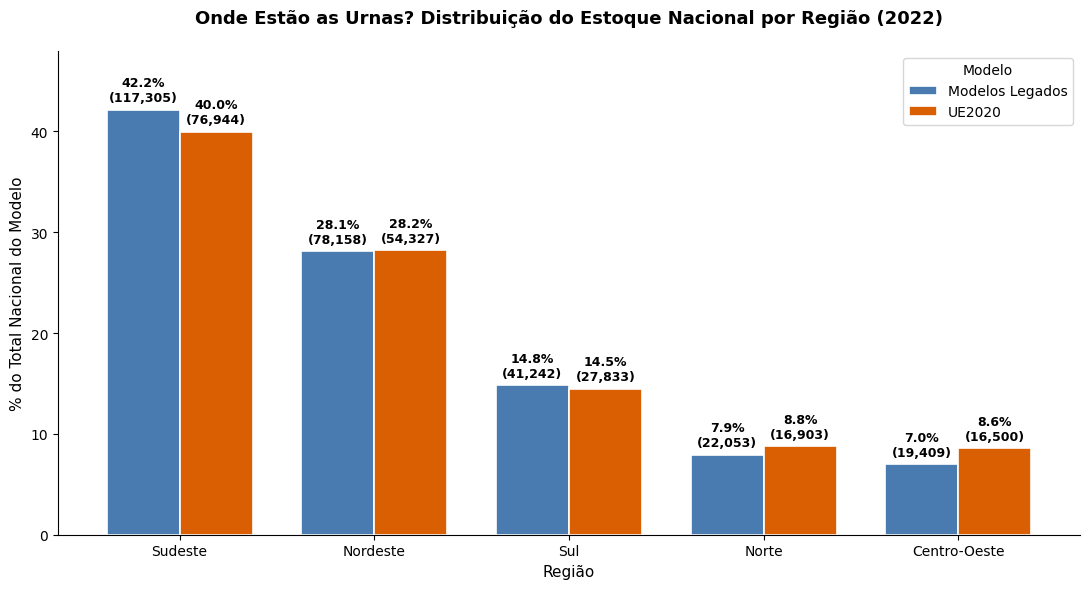

In [17]:


# 1. Tabela de distribuição percentual por coluna (sobre o total de cada modelo)
tabela_col = pd.crosstab(
    df['REGIAO'], 
    df['IS_UE2020'], 
    normalize='columns'
) * 100

tabela_col.columns = ['Modelos Legados', 'UE2020']

# Tabela com valores absolutos para os rótulos
tabela_abs = pd.crosstab(df['REGIAO'], df['IS_UE2020'])
tabela_abs.columns = ['Modelos Legados', 'UE2020']

# Ordenar pelas regiões com maior volume de UE2020
tabela_col = tabela_col.sort_values(by='UE2020', ascending=False)
tabela_abs = tabela_abs.loc[tabela_col.index]

# 2. Gráfico de Barras Agrupadas
fig, ax = plt.subplots(figsize=(11, 6))

cores = ['#4A7BB0', '#D95F02']
tabela_col.plot(
    kind='bar', 
    color=cores, 
    width=0.75, 
    edgecolor='white', 
    linewidth=1.2, 
    ax=ax
)

# Adicionar rótulos duplos: Percentual do total nacional e Quantidade absoluta
for container_idx, container in enumerate(ax.containers):
    tipo_modelo = 'Modelos Legados' if container_idx == 0 else 'UE2020'
    for i, bar in enumerate(container):
        pct = bar.get_height()
        qtd = tabela_abs.iloc[i][tipo_modelo]
        texto = f"{pct:.1f}%\n({qtd:,.0f})"
        ax.annotate(
            texto,
            xy=(bar.get_x() + bar.get_width() / 2, pct),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

ax.set_title("Onde Estão as Urnas? Distribuição do Estoque Nacional por Região (2022)", fontsize=13, pad=20, fontweight='bold')
ax.set_ylabel("% do Total Nacional do Modelo", fontsize=11)
ax.set_xlabel("Região", fontsize=11)
ax.set_ylim(0, 48)
plt.xticks(rotation=0)
ax.legend(title="Modelo", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

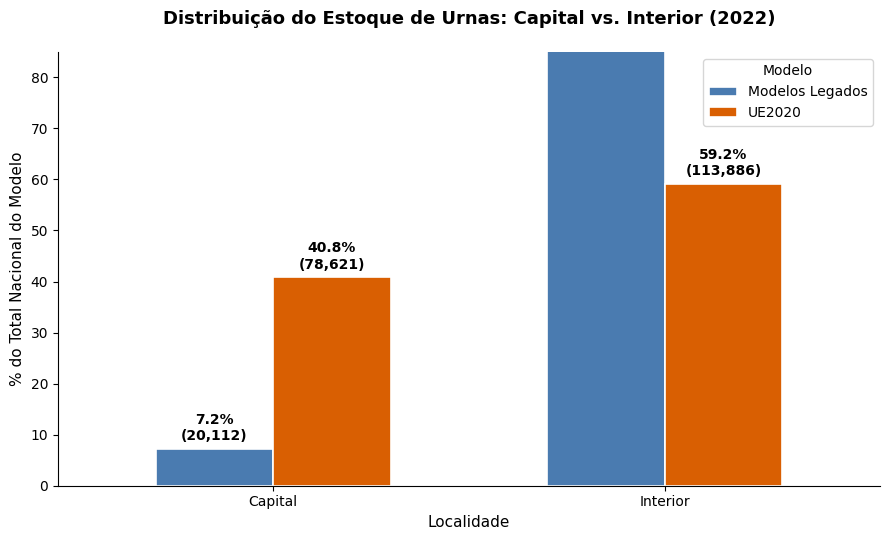

--- Proporção Interna de Cada Localidade (Penetração do Hardware) ---
                 Modelos Legados  UE2020
TIPO_LOCALIDADE                         
Capital                    20.37   79.63
Interior                   69.46   30.54

--- Volume Absoluto de Seções ---
                 Modelos Legados  UE2020
TIPO_LOCALIDADE                         
Capital                    20112   78621
Interior                  259072  113886


In [19]:
import unicodedata

# 1. Mapeamento das Capitais Brasileiras
capitais_uf = {
    'AC': 'RIO BRANCO', 'AL': 'MACEIO', 'AP': 'MACAPA', 'AM': 'MANAUS',
    'BA': 'SALVADOR', 'CE': 'FORTALEZA', 'DF': 'BRASILIA', 'ES': 'VITORIA',
    'GO': 'GOIANIA', 'MA': 'SAO LUIS', 'MT': 'CUIABA', 'MS': 'CAMPO GRANDE',
    'MG': 'BELO HORIZONTE', 'PA': 'BELEM', 'PB': 'JOAO PESSOA', 'PR': 'CURITIBA',
    'PE': 'RECIFE', 'PI': 'TERESINA', 'RJ': 'RIO DE JANEIRO', 'RN': 'NATAL',
    'RS': 'PORTO ALEGRE', 'RO': 'PORTO VELHO', 'RR': 'BOA VISTA', 'SC': 'FLORIANOPOLIS',
    'SP': 'SAO PAULO', 'SE': 'ARACAJU', 'TO': 'PALMAS'
}

def normalizar_texto(texto):
    if not isinstance(texto, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn').upper().strip()

# Criar a coluna de classificação: Capital vs Interior
df['NM_MUNICIPIO_NORM'] = df['NM_MUNICIPIO'].apply(normalizar_texto)

df['TIPO_LOCALIDADE'] = df.apply(
    lambda r: 'Capital' if capitais_uf.get(r['SG_UF']) == r['NM_MUNICIPIO_NORM'] or r['SG_UF'] == 'DF' else 'Interior',
    axis=1
)

# 2. Tabelas de Distribuição
tabela_abs_cap = pd.crosstab(df['TIPO_LOCALIDADE'], df['IS_UE2020'])
tabela_abs_cap.columns = ['Modelos Legados', 'UE2020']

tabela_col_cap = pd.crosstab(df['TIPO_LOCALIDADE'], df['IS_UE2020'], normalize='columns') * 100
tabela_col_cap.columns = ['Modelos Legados', 'UE2020']

tabela_row_cap = pd.crosstab(df['TIPO_LOCALIDADE'], df['IS_UE2020'], normalize='index') * 100
tabela_row_cap.columns = ['Modelos Legados', 'UE2020']

# 3. Gráfico Comparativo de Distribuição do Estoque Nacional
fig, ax = plt.subplots(figsize=(9, 5.5))

cores = ['#4A7BB0', '#D95F02']
tabela_col_cap.plot(
    kind='bar',
    color=cores,
    width=0.6,
    edgecolor='white',
    linewidth=1.2,
    ax=ax
)

for container_idx, container in enumerate(ax.containers):
    tipo_modelo = 'Modelos Legados' if container_idx == 0 else 'UE2020'
    for i, bar in enumerate(container):
        pct = bar.get_height()
        qtd = tabela_abs_cap.iloc[i][tipo_modelo]
        texto = f"{pct:.1f}%\n({qtd:,.0f})"
        ax.annotate(
            texto,
            xy=(bar.get_x() + bar.get_width() / 2, pct),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=10, fontweight='bold'
        )

ax.set_title("Distribuição do Estoque de Urnas: Capital vs. Interior (2022)", fontsize=13, pad=20, fontweight='bold')
ax.set_ylabel("% do Total Nacional do Modelo", fontsize=11)
ax.set_xlabel("Localidade", fontsize=11)
ax.set_ylim(0, 85)
plt.xticks(rotation=0)
ax.legend(title="Modelo", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

# 4. Exibição dos dados textuais
print("--- Proporção Interna de Cada Localidade (Penetração do Hardware) ---")
print(tabela_row_cap.round(2))
print("\n--- Volume Absoluto de Seções ---")
print(tabela_abs_cap)

## visualização das distribuições de votos

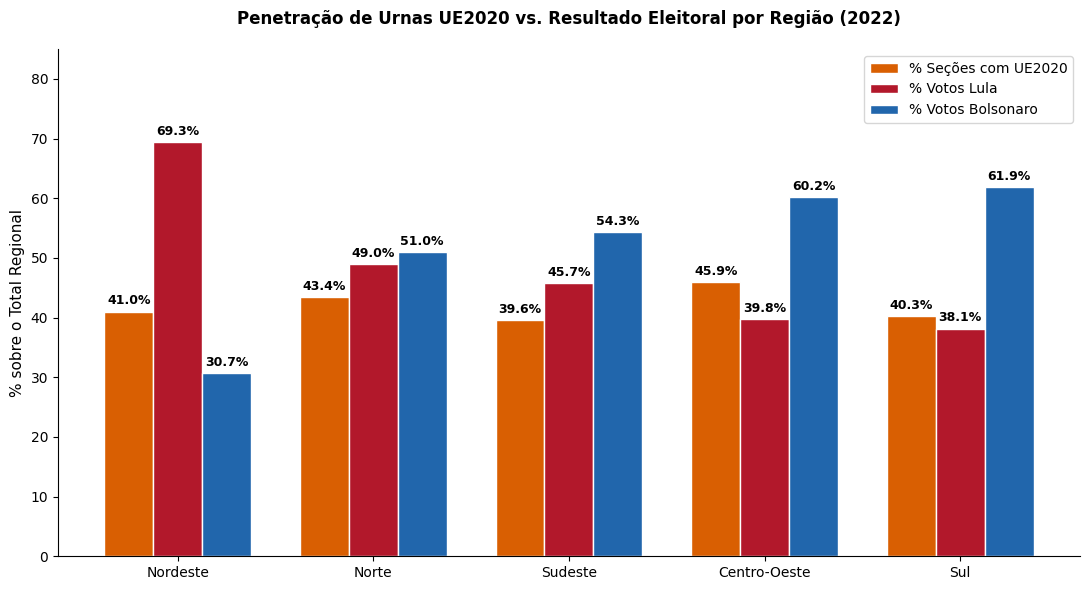

In [20]:


# 1. Agregação por Região
resumo_regiao = df.groupby('REGIAO').agg(
    total_secoes=('NR_SECAO', 'count'),
    secoes_ue2020=('IS_UE2020', 'sum'),
    votos_lula=('LULA', 'sum'),
    votos_bolsonaro=('JAIR BOLSONARO', 'sum')
).reset_index()

resumo_regiao['TOTAL_VALIDOS'] = resumo_regiao['votos_lula'] + resumo_regiao['votos_bolsonaro']
resumo_regiao['PCT_UE2020'] = (resumo_regiao['secoes_ue2020'] / resumo_regiao['total_secoes']) * 100
resumo_regiao['PCT_LULA'] = (resumo_regiao['votos_lula'] / resumo_regiao['TOTAL_VALIDOS']) * 100
resumo_regiao['PCT_BOLSONARO'] = (resumo_regiao['votos_bolsonaro'] / resumo_regiao['TOTAL_VALIDOS']) * 100

# Ordenar por votação de Lula
resumo_regiao = resumo_regiao.sort_values(by='PCT_LULA', ascending=False).reset_index(drop=True)

# 2. Plotagem Lado a Lado
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(resumo_regiao))
width = 0.25

rects1 = ax.bar(x - width, resumo_regiao['PCT_UE2020'], width, label='% Seções com UE2020', color='#D95F02', edgecolor='white')
rects2 = ax.bar(x, resumo_regiao['PCT_LULA'], width, label='% Votos Lula', color='#B2182B', edgecolor='white')
rects3 = ax.bar(x + width, resumo_regiao['PCT_BOLSONARO'], width, label='% Votos Bolsonaro', color='#2166AC', edgecolor='white')

# Rótulos nas barras
for rects in [rects1, rects2, rects3]:
    for bar in rects:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Penetração de Urnas UE2020 vs. Resultado Eleitoral por Região (2022)", fontsize=12, pad=18, fontweight='bold')
ax.set_ylabel("% sobre o Total Regional", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(resumo_regiao['REGIAO'], fontsize=10)
ax.set_ylim(0, 85)
ax.legend(frameon=True, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

# . O Gráfico Regional: A Desconexão entre Hardware e Voto
o argumento de interferência do equipamento se desfaz:

Penetração homogênea do hardware entre macrorregiões: A taxa de urnas UE2020 oscilou em uma faixa estreita entre as regiões: 39,6% no Sudeste, 40,3% no Sul, 41,0% no Nordeste, 43,4% no Norte e 45,9% no Centro-Oeste.

Comportamento eleitoral amplamente divergente: Enquanto a presença do hardware UE2020 ficou estável em torno de 40% a 45% em todas as regiões, a votação variou drasticamente por fatores político-culturais:

No Nordeste, com 41,0% de UE2020, Lula fez 69,3% dos votos.

No Sul, com praticamente a mesma taxa de novas urnas (40,3%), Bolsonaro fez 61,9%.

No Centro-Oeste, a região com a maior taxa de UE2020 do país (45,9%), Bolsonaro venceu com 60,2%.

Se o equipamento induzisse desvios na contagem, regiões com taxas idênticas de novas urnas (como Nordeste com 41% e Sul com 40,3%) teriam comportamentos similares, o que evidentemente não ocorreu.

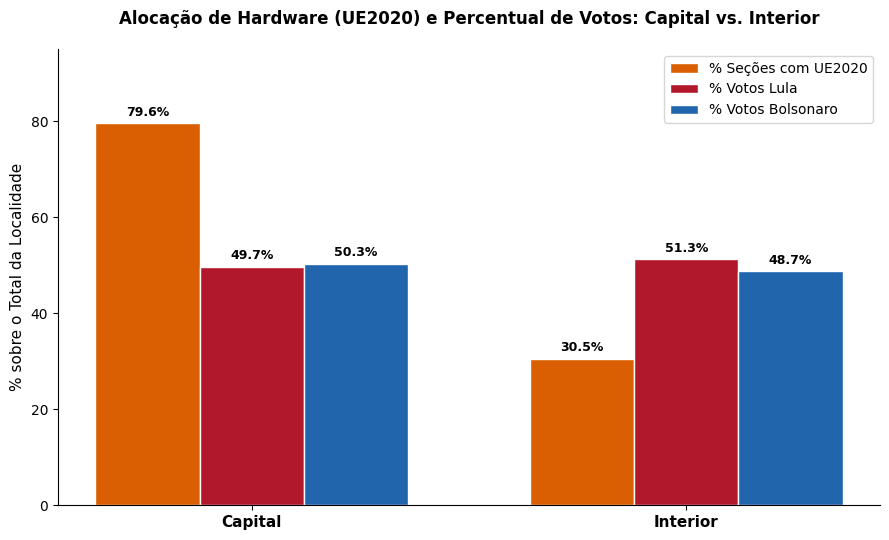

In [21]:
# 1. Agregação por Tipo de Localidade (Capital vs Interior)
resumo_loc = df.groupby('TIPO_LOCALIDADE').agg(
    total_secoes=('NR_SECAO', 'count'),
    secoes_ue2020=('IS_UE2020', 'sum'),
    votos_lula=('LULA', 'sum'),
    votos_bolsonaro=('JAIR BOLSONARO', 'sum')
).reset_index()

resumo_loc['TOTAL_VALIDOS'] = resumo_loc['votos_lula'] + resumo_loc['votos_bolsonaro']
resumo_loc['PCT_UE2020'] = (resumo_loc['secoes_ue2020'] / resumo_loc['total_secoes']) * 100
resumo_loc['PCT_LULA'] = (resumo_loc['votos_lula'] / resumo_loc['TOTAL_VALIDOS']) * 100
resumo_loc['PCT_BOLSONARO'] = (resumo_loc['votos_bolsonaro'] / resumo_loc['TOTAL_VALIDOS']) * 100

# 2. Plotagem Comparativa
fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(resumo_loc))
width = 0.24

rects1 = ax.bar(x - width, resumo_loc['PCT_UE2020'], width, label='% Seções com UE2020', color='#D95F02', edgecolor='white')
rects2 = ax.bar(x, resumo_loc['PCT_LULA'], width, label='% Votos Lula', color='#B2182B', edgecolor='white')
rects3 = ax.bar(x + width, resumo_loc['PCT_BOLSONARO'], width, label='% Votos Bolsonaro', color='#2166AC', edgecolor='white')

for rects in [rects1, rects2, rects3]:
    for bar in rects:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title("Alocação de Hardware (UE2020) e Percentual de Votos: Capital vs. Interior", fontsize=12, pad=18, fontweight='bold')
ax.set_ylabel("% sobre o Total da Localidade", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(resumo_loc['TIPO_LOCALIDADE'], fontsize=11, fontweight='bold')
ax.set_ylim(0, 95)
ax.legend(frameon=True, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

 ## O Gráfico Capital vs. Interior 
 A Origem Direta do Viés de 4,19 p.p.No primeiro gráfico, a discrepância de hardware é extrema:Capitais: 79,6% das seções operaram com UE2020. Nesse estrato, Bolsonaro venceu por 50,3% vs. 49,7% (uma vantagem de $+0{,}6$ p.p.).Interior: Apenas 30,5% das seções tiveram UE2020 (69,5% foram legadas). No interior, Lula venceu por 51,3% vs. 48,7% (uma vantagem de $+2{,}6$ p.p.).Como quase 80% das capitais tinham urnas novas e quase 70% do interior tinha urnas legadas, qualquer agregação ingênua que calcule a "média nacional por modelo de urna" está simplesmente comparando a preferência eleitoral média das capitais com a do interior.